# Grid Search

## Baseline

===== ÉVALUATION (CV=5 folds) POUR : **xgboost** (SMOTE=False, Scaler=none) =====

--- Scores de Validation Croisée (moyenne) ---

| Métrique | Score | Écart-type |
| :--- | :--- | :--- |
| Accuracy | 0.8592 | +- 0.0199 |
| Precision | 0.7452 | +- 0.0506 |
| Recall | 0.6743 | +- 0.0327 |
| F1-Score | 0.6989 | +- 0.0384 |

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.pipeline import Pipeline  # Utiliser la Pipeline standard de Scikit-learn
from sklearn.preprocessing import OneHotEncoder


In [10]:
df = pd.read_csv("processed/data_merge_p2.csv")
X = df.drop('a_quitte_l_entreprise', axis=1)
y = df['a_quitte_l_entreprise']
colonnes_categorielles = ['frequence_deplacement', 
                          'domaine_etude', 
                          'poste', 
                          'departement', 
                          'statut_marital']
colonnes_numeriques = X.select_dtypes(include=np.number).columns

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        # Applique OneHotEncoder aux colonnes catégorielles
        ('onehot', OneHotEncoder(handle_unknown='ignore'), colonnes_categorielles),
        
        # 'passthrough' pour les colonnes numériques (pas de scaling)
        ('scaler', 'passthrough', colonnes_numeriques)
    ],
    remainder='passthrough'
)

In [12]:
# Puisque SMOTE n'est pas utilisé, on utilise 'scale_pos_weight' pour gérer le déséquilibre
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
model_xgb = xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)

In [13]:
# ('preprocessor' pour les étapes de transfo, 'model' pour l'estimateur)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model_xgb) # 'model' est le nom que nous donnons à l'étape XGBoost
])

In [18]:
# ATTENTION : Les noms DOIVENT commencer par le nom de l'étape : 'model__'
param_grid = {
    'model__n_estimators': [100, 200, 300],       # Nombre d'arbres
    'model__max_depth': [3, 5, 7],             # Profondeur max des arbres
    'model__learning_rate': [0.01, 0.1],      # Taux d'apprentissage
    # min_child_weight : Poids minimum requis dans un "enfant" (feuille).
    # Une valeur plus élevée rend le modèle plus conservateur.
    'model__min_child_weight': [1, 3, 5],
    # subsample : Fraction d'échantillons (lignes) utilisée pour chaque arbre.
    # 0.8 signifie que chaque arbre est entraîné sur 80% des données.
    'model__subsample': [0.8, 1.0],
    # colsample_bytree : Fraction de features (colonnes) utilisée pour chaque arbre.
    'model__colsample_bytree': [0.8, 1.0]
}

In [19]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("--- Lancement du GridSearchCV pour XGBoost ---")

grid_search = GridSearchCV(
    estimator=pipeline,       # On passe la pipeline complète !
    param_grid=param_grid,    # La grille de paramètres préfixée
    scoring='f1_macro',       # Métrique pertinente pour données déséquilibrées
    cv=cv_strategy,           # Notre stratégie de CV stratifiée
    n_jobs=-1,                # Utiliser tous les processeurs
    verbose=1                 # Afficher la progression
)

--- Lancement du GridSearchCV pour XGBoost ---


In [20]:
grid_search.fit(X, y)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('onehot', ...), ('scaler', ...)]"


In [21]:
print("\n--- RÉSULTATS DU GRIDSEARCH ---")
print(f"Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)

print(f"\nMeilleur score (f1_macro) sur la validation croisée :")
print(f"{grid_search.best_score_:.4f}")

# 9. Utiliser le meilleur modèle
# 'grid_search' est maintenant le meilleur modèle, ré-entraîné sur TOUT X et y
best_model = grid_search.best_estimator_


--- RÉSULTATS DU GRIDSEARCH ---
Meilleurs hyperparamètres trouvés :
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}

Meilleur score (f1_macro) sur la validation croisée :
0.7481


--- Analyse 1 : Importance Native (Gain) ---


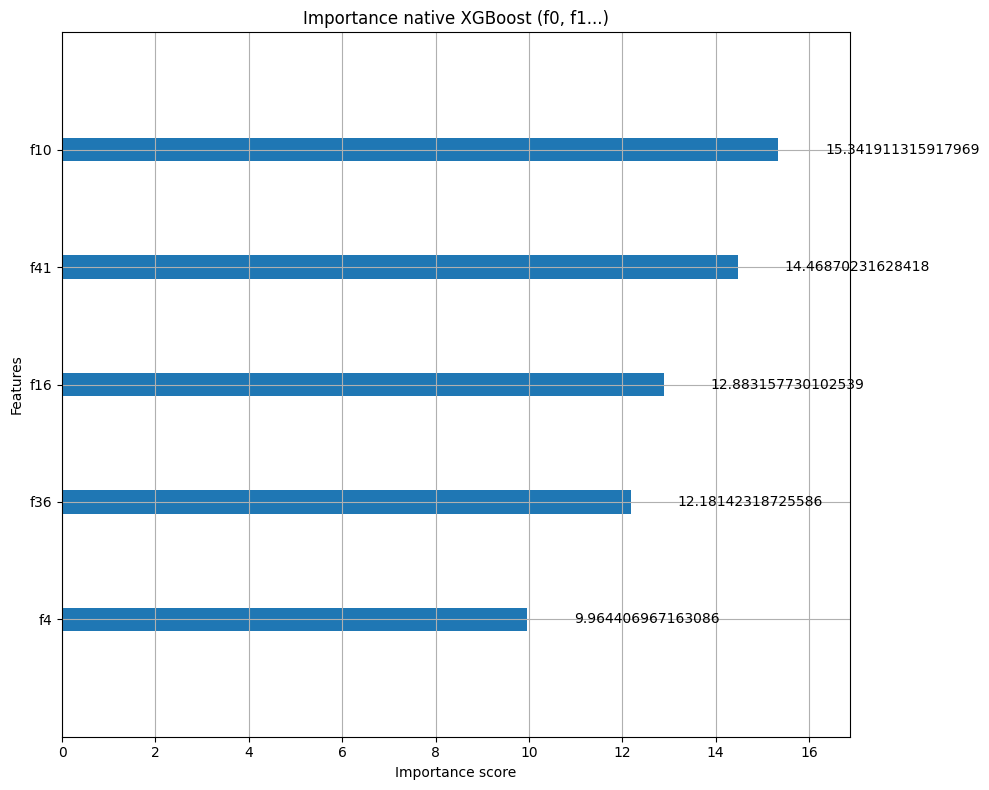

In [25]:


best_pipeline = grid_search.best_estimator_
best_xgb_model = best_pipeline.named_steps['model']
trained_preprocessor = best_pipeline.named_steps['preprocessor']
print("--- Analyse 1 : Importance Native (Gain) ---")

fig, ax = plt.subplots(figsize=(10, 8))
try:
    xgb.plot_importance(best_xgb_model, 
                        ax=ax, 
                        importance_type='gain', 
                        max_num_features=5,
                        title="Importance native XGBoost (f0, f1...)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erreur lors de l'affichage de plot_importance (attendu si les noms manquent) : {e}")

In [ ]:


print("\n--- Analyse 2 : Interprétabilité avec SHAP ---")
feature_names = trained_preprocessor.get_feature_names_out()
X_processed = trained_preprocessor.transform(X)
explainer = shap.TreeExplainer(best_xgb_model)